In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pour que Jupyter reconnaisse src/
sys.path.append(os.path.abspath(".."))

# Style pro
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


In [3]:
# MovieLens
movies = pd.read_csv("../data/movies.csv")
ratings = pd.read_csv("../data/ratings.csv")

# IMDb
imdb = pd.read_csv("../data/title.basics.tsv", sep="\t", low_memory=False)


In [4]:
movies.head()
ratings.head()
imdb.head()


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short"
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892,\N,5,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,\N,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,\N,1,Short


In [5]:
imdb_movies = imdb[imdb["titleType"] == "movie"].copy()

# Colonnes utiles
imdb_movies = imdb_movies[
    ["tconst", "primaryTitle", "startYear", "genres"]
]

# Nettoyage
imdb_movies = imdb_movies.replace("\\N", np.nan)
imdb_movies.dropna(subset=["primaryTitle"], inplace=True)

imdb_movies.head()


,tconst,primaryTitle,startYear,genres
8,tt0000009,Miss Jerry,1894,Romance
144,tt0000147,The Corbett-Fitzsimmons Fight,1897,"Documentary,News,Sport"
331,tt0000335,Soldiers of the Cross,1900,"Biography,Drama"
498,tt0000502,Bohemios,1905,NaN
570,tt0000574,The Story of the Kelly Gang,1906,"Action,Adventure,Biography"


In [6]:
movies["genres"] = movies["genres"].str.replace("|", " ", regex=False)
ratings = ratings[ratings["rating"] >= 0]


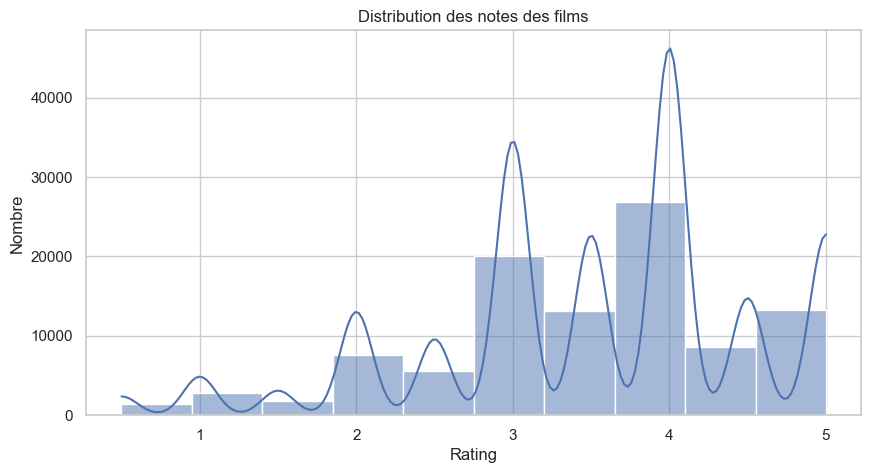

In [7]:
sns.histplot(ratings["rating"], bins=10, kde=True)
plt.title("Distribution des notes des films")
plt.xlabel("Rating")
plt.ylabel("Nombre")
plt.savefig("../app/static/ratings_distribution.png")
plt.show()


In [8]:
top_movies = (
    ratings.groupby("movieId")
    .agg({"rating": ["mean", "count"]})
)

top_movies.columns = ["avg_rating", "num_ratings"]
top_movies = top_movies[top_movies["num_ratings"] > 100]

top_movies = top_movies.sort_values("avg_rating", ascending=False).head(10)

top_movies


,avg_rating,num_ratings
movieId,,
318,4.429022,317
858,4.289062,192
2959,4.272936,218
1221,4.259690,129
48516,4.252336,107
1213,4.250000,126
58559,4.238255,149
50,4.237745,204
1197,4.232394,142


In [9]:
movie_stats = ratings.groupby("movieId").agg(
    avg_rating=("rating", "mean"),
    num_votes=("rating", "count")
).reset_index()

movies_merged = movies.merge(movie_stats, on="movieId")

movies_merged.head()


,movieId,title,genres,avg_rating,num_votes
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,3.920930,215
1,2,Jumanji (1995),Adventure Children Fantasy,3.431818,110
2,3,Grumpier Old Men (1995),Comedy Romance,3.259615,52
3,4,Waiting to Exhale (1995),Comedy Drama Romance,2.357143,7
4,5,Father of the Bride Part II (1995),Comedy,3.071429,49


In [10]:
movies_merged.to_csv("../data/movies_clean.csv", index=False)
ratings.to_csv("../data/ratings_clean.csv", index=False)
imdb_movies.to_csv("../data/imdb_clean.csv", index=False)
